In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data_source/breast_cancer_dataset.csv')

## Checking the dataset for cleaning

In [3]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
df.shape          # should be (569, 31)


(569, 33)

In [7]:
df.drop(['Unnamed: 32','id'], axis=1, inplace=True)

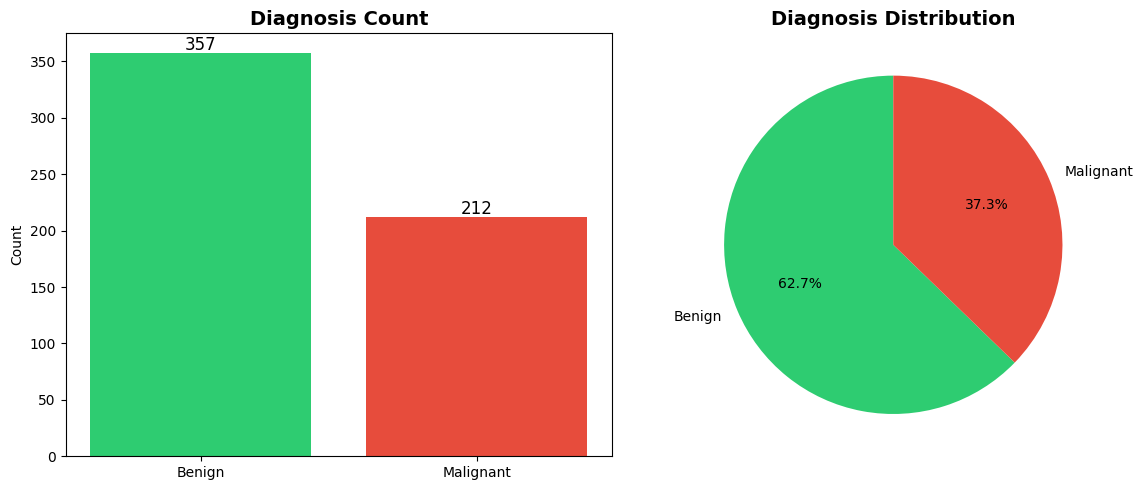

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
counts = df['diagnosis'].value_counts()
axes[0].bar(['Benign', 'Malignant'], counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Diagnosis Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, val in enumerate(counts.values):
    axes[0].text(i, val + 3, str(val), ha='center', fontsize=12)

# pie chart
axes[1].pie(counts.values, labels=['Benign', 'Malignant'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Diagnosis Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/diagnosis_distribution.png', dpi=150)
plt.show()

In [30]:
counts

B    357
M    212
Name: diagnosis, dtype: int64

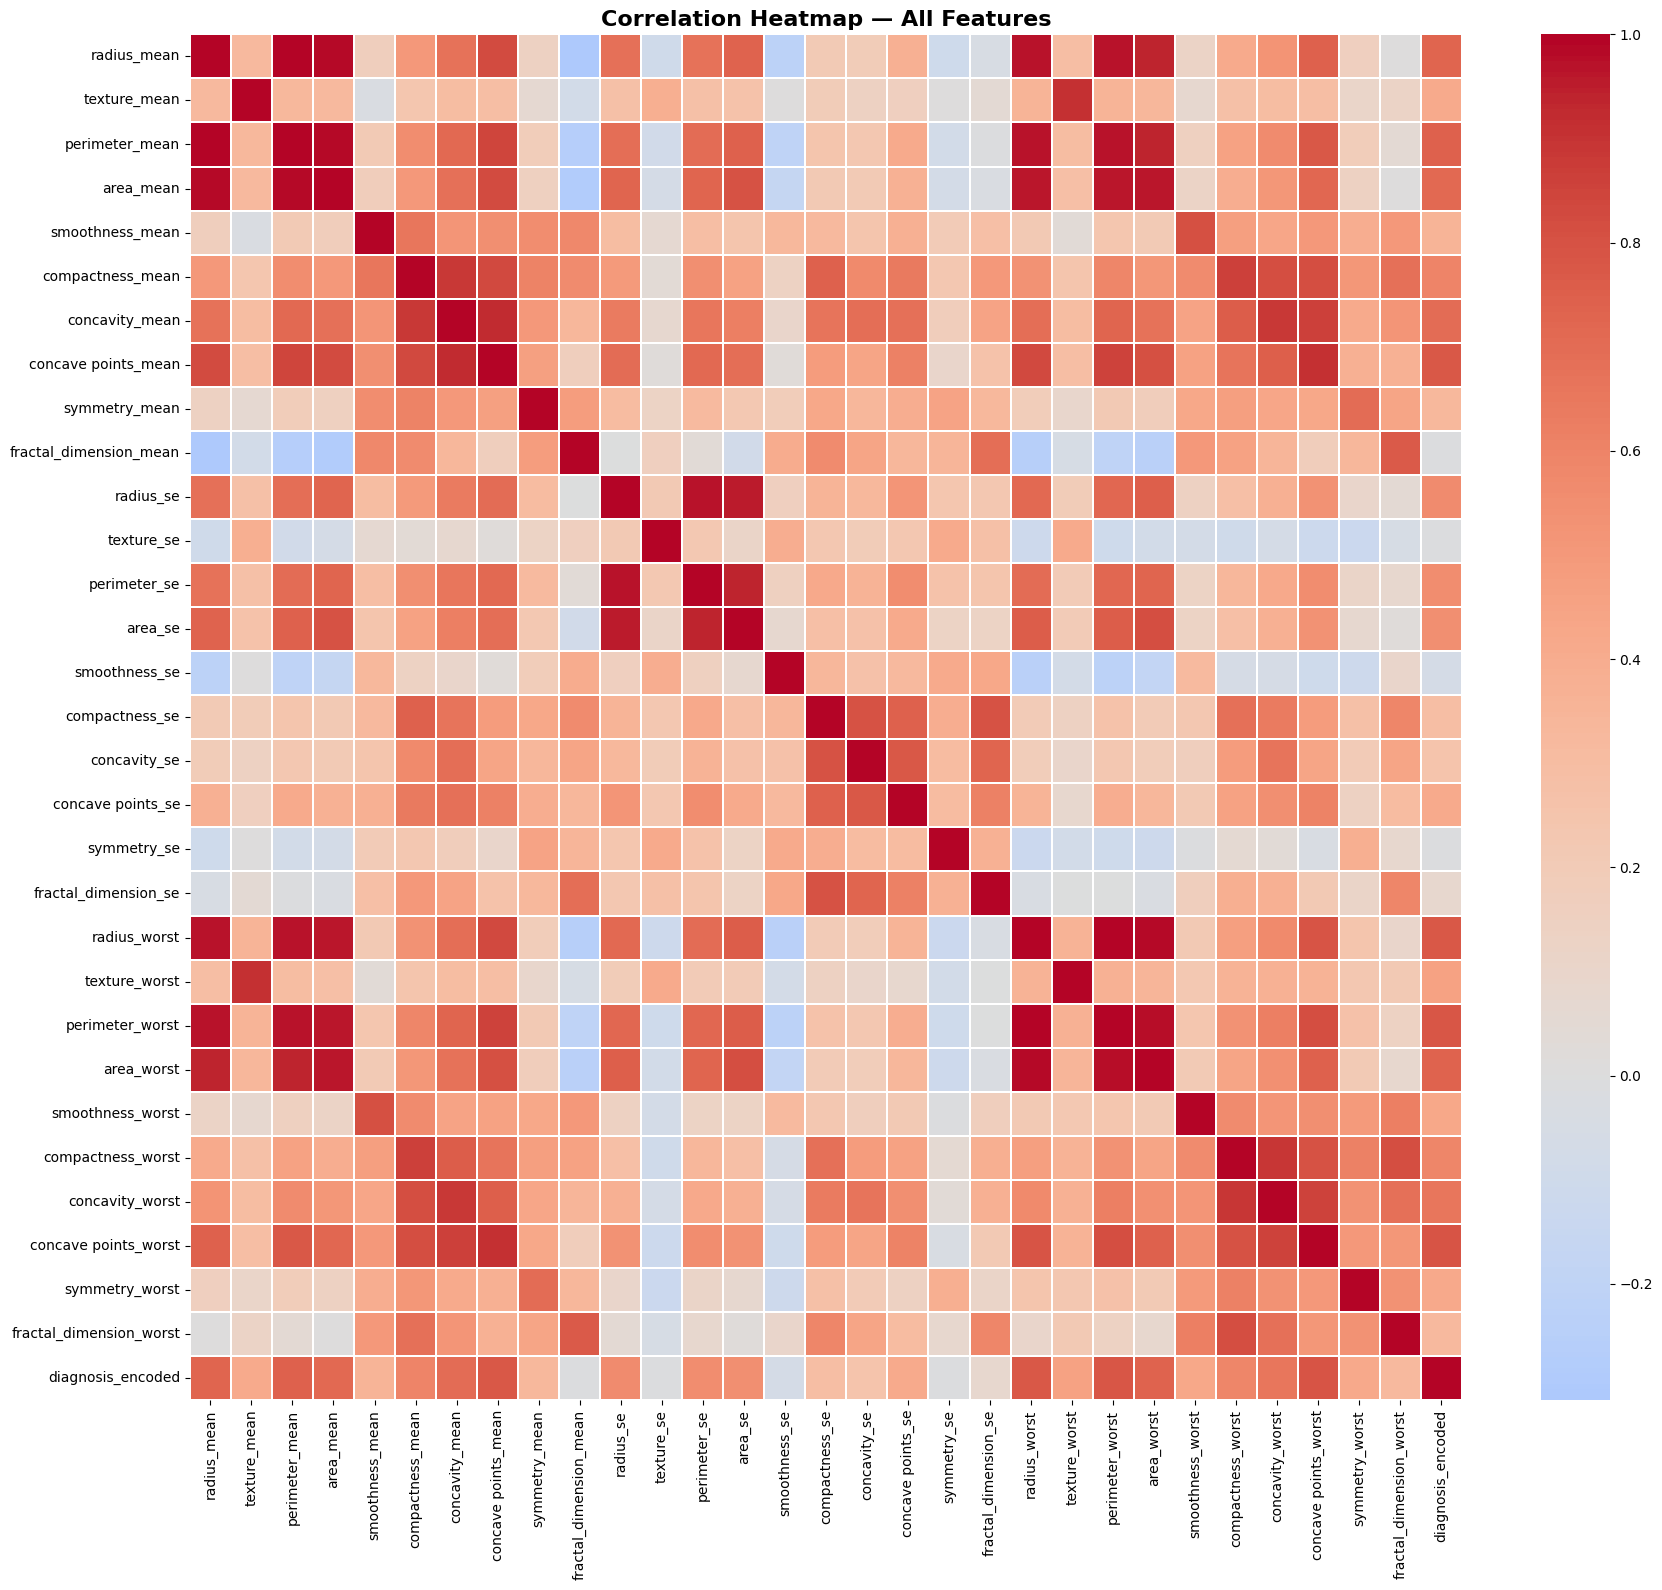

In [32]:
fig, ax = plt.subplots(figsize=(18, 16))

corr = df.drop(columns='diagnosis').corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0,
            linewidths=0.1, ax=ax)

ax.set_title('Correlation Heatmap — All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap_all.png', dpi=150)
plt.show()

In [10]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


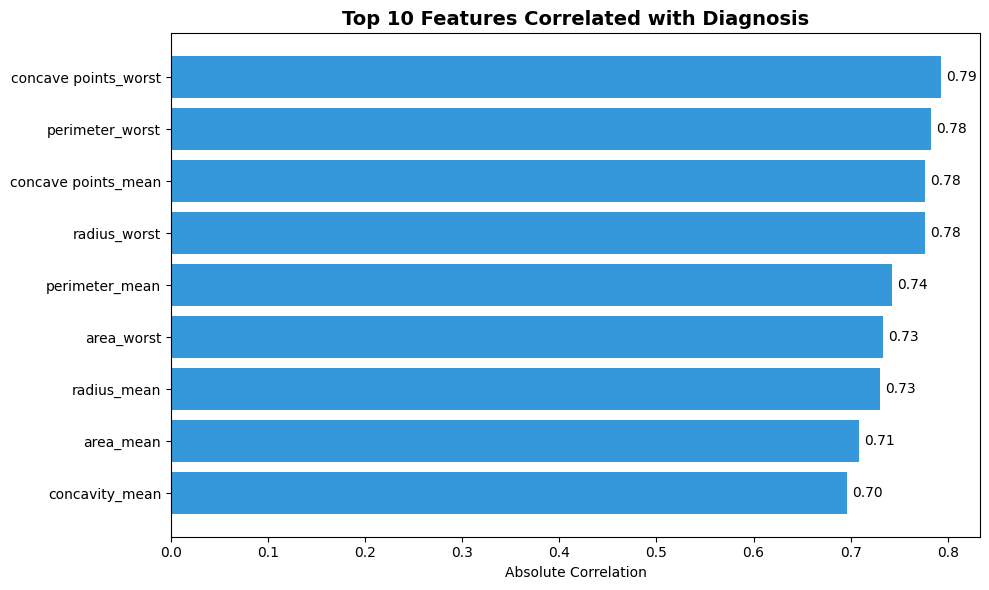

In [20]:
df['diagnosis_encoded'] = df['diagnosis'].map({'M': 1, 'B': 0})
fig, ax = plt.subplots(figsize=(10, 6))

corr_with_diagnosis = df.drop(columns='diagnosis').corrwith(
    df['diagnosis_encoded']).abs().sort_values(ascending=False).head(10)
corr_with_diagnosis = corr_with_diagnosis.drop('diagnosis_encoded')

bars = ax.barh(corr_with_diagnosis.index, corr_with_diagnosis.values,
               color='#3498db')
ax.set_title('Top 10 Features Correlated with Diagnosis', fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.invert_yaxis()

for bar, val in zip(bars, corr_with_diagnosis.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/top10_corr_diagnosis.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/2294199520.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/2294199520.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/2294199520.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/229419

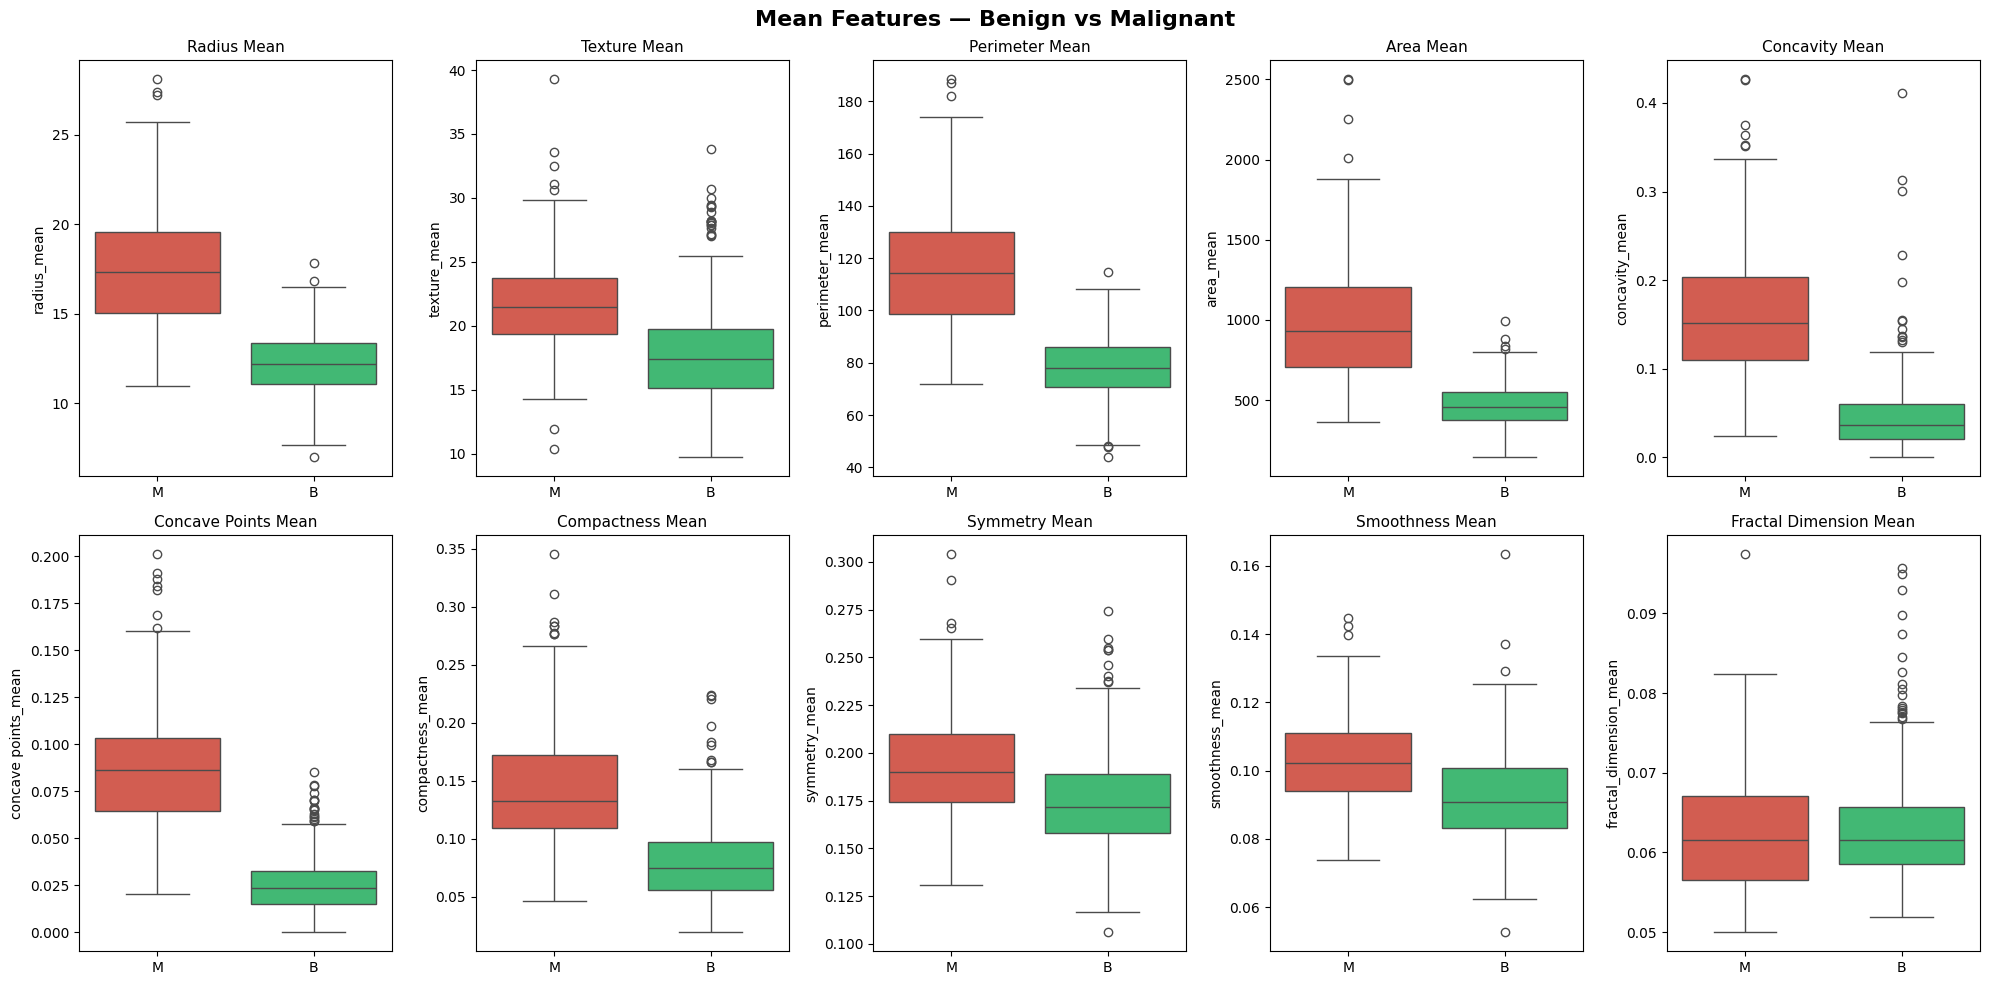

In [14]:
palette = {'M': '#e74c3c', 'B': '#2ecc71'}

mean_features = ['radius_mean', 'texture_mean', 'perimeter_mean',
                 'area_mean', 'concavity_mean', 'concave points_mean',
                 'compactness_mean', 'symmetry_mean',
                 'smoothness_mean', 'fractal_dimension_mean']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.boxplot(data=df, x='diagnosis', y=col,
                palette=palette, ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('')

fig.suptitle('Mean Features — Benign vs Malignant', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/boxplots_mean_features.png', dpi=150)
plt.show()

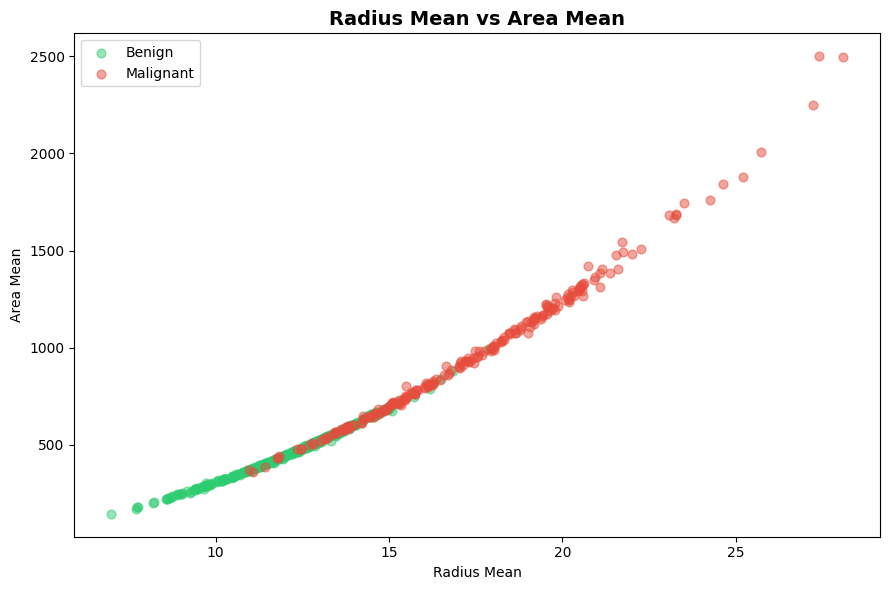

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for diagnosis, color in [('B', '#2ecc71'), ('M', "#e74c3c")]:
    subset = df[df['diagnosis'] == diagnosis]
    ax.scatter(subset['radius_mean'], subset['area_mean'],
               c=color, alpha=0.5, s=40,
               label='Benign' if diagnosis == 'B' else 'Malignant')

ax.set_title('Radius Mean vs Area Mean', fontsize=14, fontweight='bold')
ax.set_xlabel('Radius Mean')
ax.set_ylabel('Area Mean')
ax.legend()

plt.tight_layout()
plt.savefig('visualizations/scatter_radius_area.png', dpi=150)
plt.show()

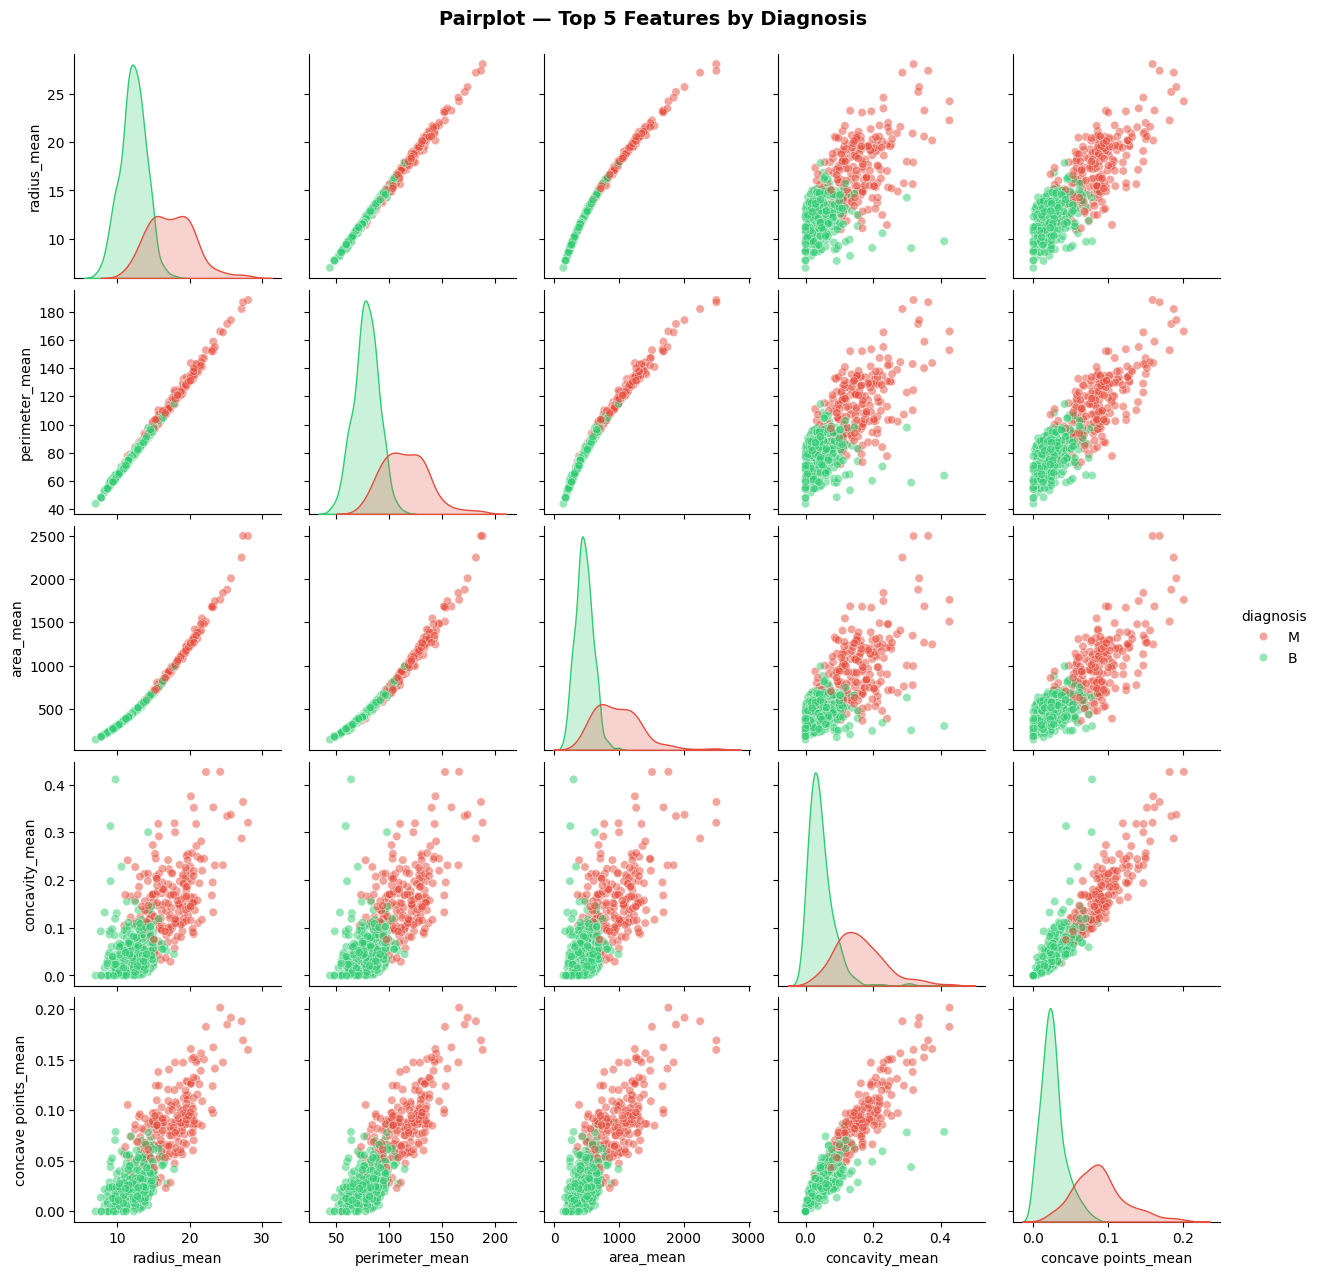

In [16]:
top5 = ['radius_mean', 'perimeter_mean', 'area_mean',
        'concavity_mean', 'concave points_mean', 'diagnosis']

pair = sns.pairplot(df[top5], hue='diagnosis',
                    palette=palette, plot_kws={'alpha': 0.5}, height=2.5)
pair.fig.suptitle('Pairplot — Top 5 Features by Diagnosis',
                  fontsize=14, fontweight='bold', y=1.02)

plt.savefig('visualizations/pairplot_top5.png', dpi=150, bbox_inches='tight')
plt.show()

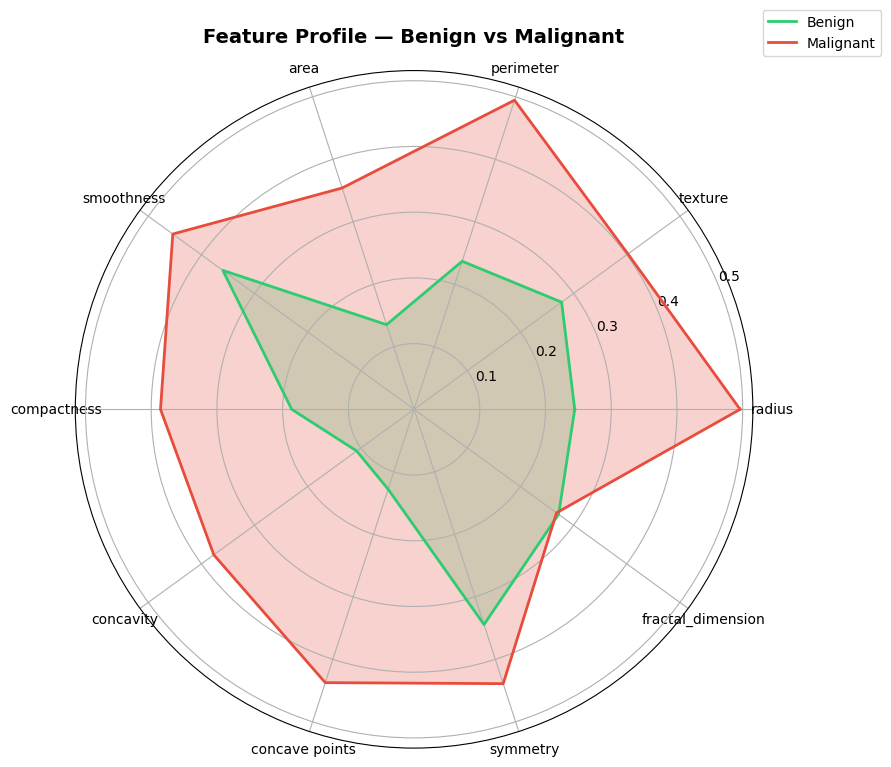

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
mean_features = [c for c in df.columns if '_mean' in c]

# normalize each feature across the whole dataset first
df_scaled = df.copy()
df_scaled[mean_features] = scaler.fit_transform(df[mean_features])

# then take group means
benign_norm = df_scaled[df_scaled['diagnosis']=='B'][mean_features].mean().values
malignant_norm = df_scaled[df_scaled['diagnosis']=='M'][mean_features].mean().values

# rest of radar chart code stays the same
angles = np.linspace(0, 2*np.pi, len(mean_features), endpoint=False).tolist()
benign_norm = np.concatenate((benign_norm, [benign_norm[0]]))
malignant_norm = np.concatenate((malignant_norm, [malignant_norm[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles, benign_norm, color='#2ecc71', linewidth=2, label='Benign')
ax.fill(angles, benign_norm, color='#2ecc71', alpha=0.25)
ax.plot(angles, malignant_norm, color='#e74c3c', linewidth=2, label='Malignant')
ax.fill(angles, malignant_norm, color='#e74c3c', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_mean','') for f in mean_features], fontsize=10)
ax.set_title('Feature Profile — Benign vs Malignant', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.savefig('visualizations/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
df.groupby('diagnosis')[['symmetry_mean', 'fractal_dimension_mean']].mean()


,symmetry_mean,fractal_dimension_mean
diagnosis,,
B,0.174186,0.062867
M,0.192909,0.062680


/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/3182399612.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/3182399612.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/3182399612.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/318239

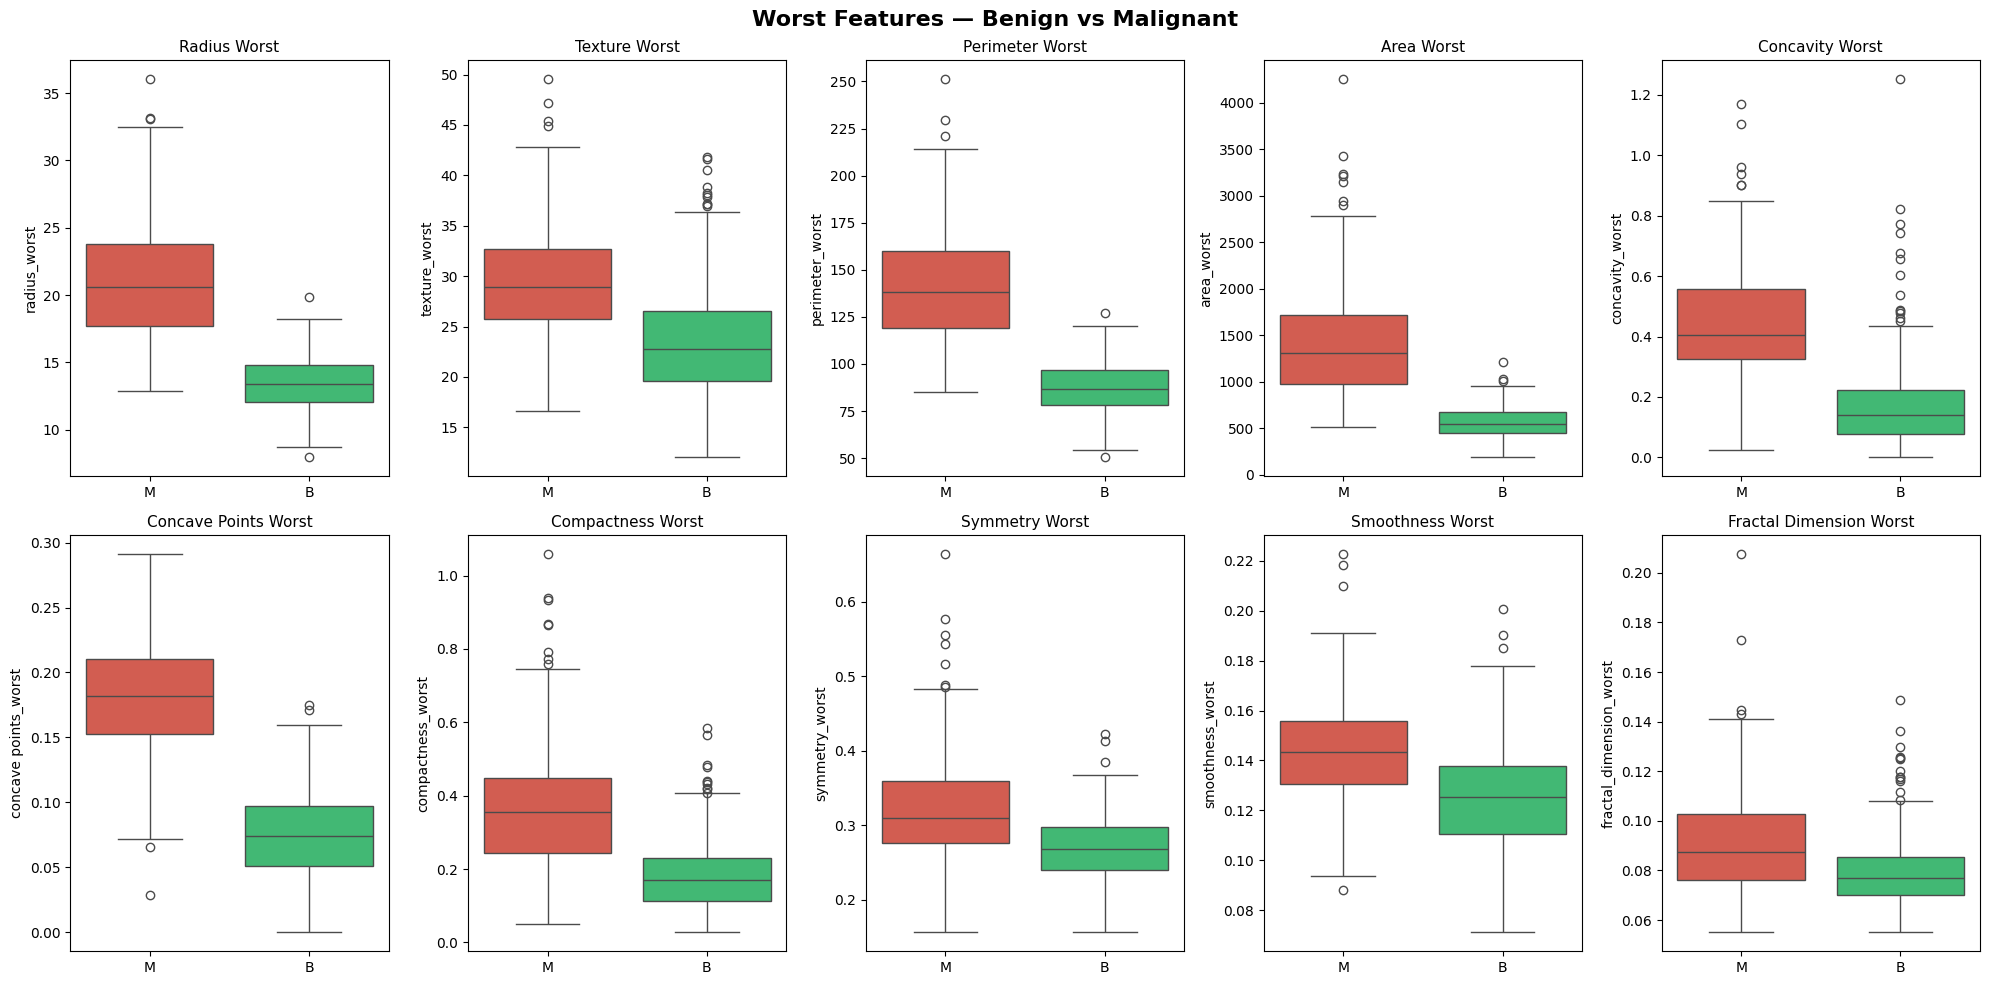

In [22]:
worst_features = ['radius_worst', 'texture_worst', 'perimeter_worst',
                  'area_worst', 'concavity_worst', 'concave points_worst',
                  'compactness_worst', 'symmetry_worst',
                  'smoothness_worst', 'fractal_dimension_worst']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(worst_features):
    sns.boxplot(data=df, x='diagnosis', y=col,
                palette=palette, ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('')

fig.suptitle('Worst Features — Benign vs Malignant', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/boxplots_worst_features.png', dpi=150)
plt.show()

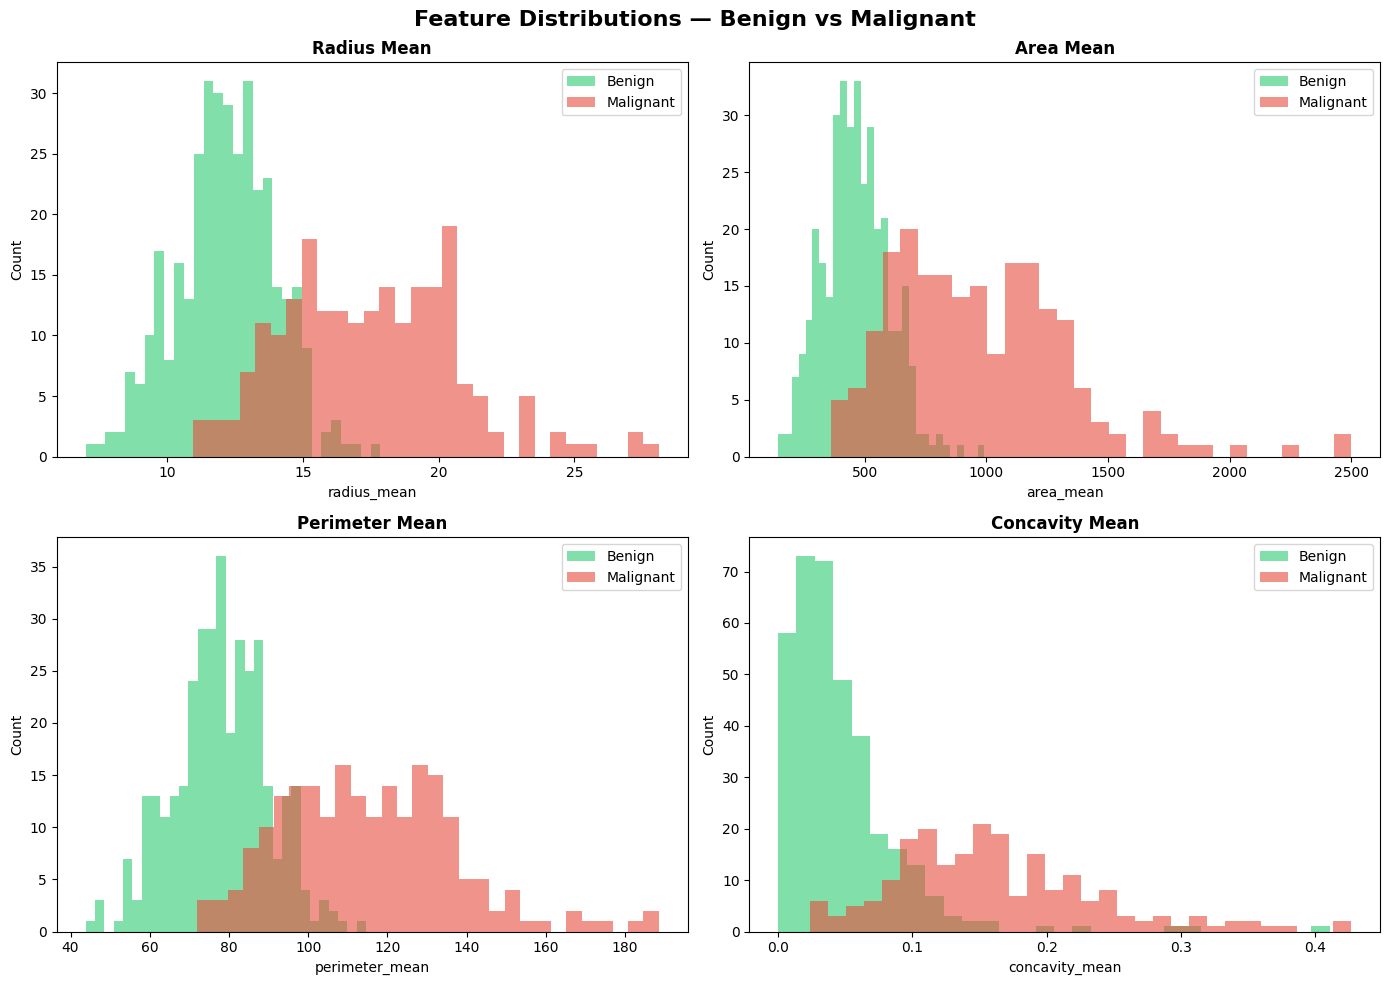

In [23]:
key_features = ['radius_mean', 'area_mean', 'perimeter_mean', 'concavity_mean']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].hist(df[df['diagnosis']=='B'][col], bins=30,
                 alpha=0.6, color='#2ecc71', label='Benign')
    axes[i].hist(df[df['diagnosis']=='M'][col], bins=30,
                 alpha=0.6, color='#e74c3c', label='Malignant')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

fig.suptitle('Feature Distributions — Benign vs Malignant', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/histograms_key_features.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/2643200746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/2643200746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/2643200746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/

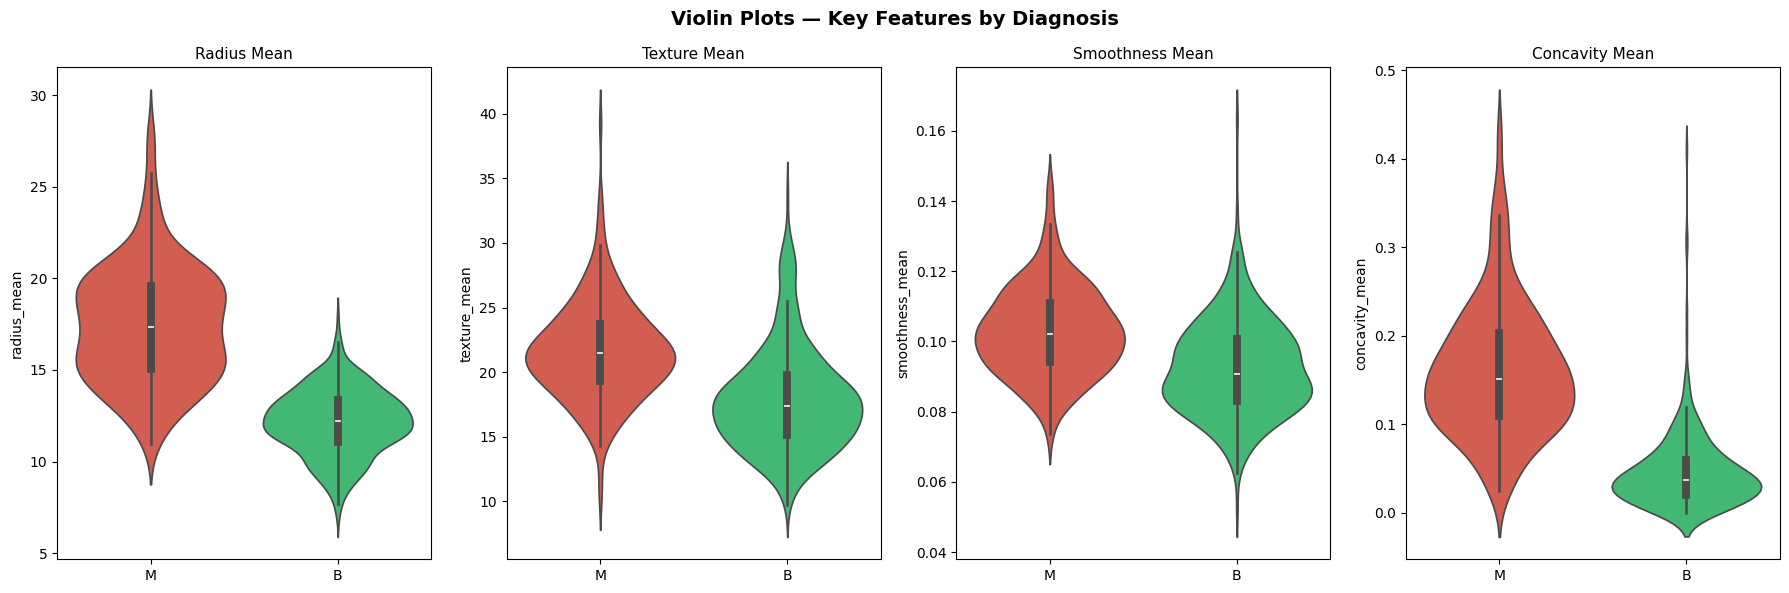

In [24]:
violin_features = ['radius_mean', 'texture_mean', 'smoothness_mean', 'concavity_mean']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, col in enumerate(violin_features):
    sns.violinplot(data=df, x='diagnosis', y=col,
                   palette=palette, ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('')

fig.suptitle('Violin Plots — Key Features by Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/violin_plots.png', dpi=150)
plt.show()

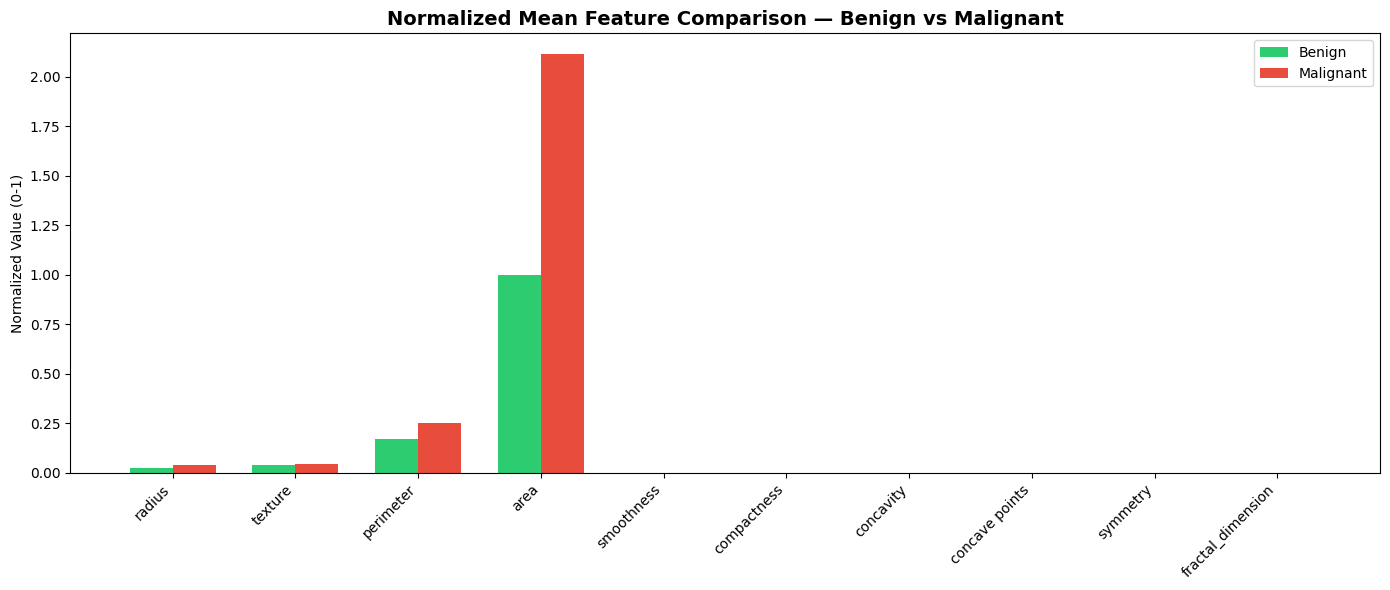

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

mean_features = [c for c in df.columns if '_mean' in c]
benign_means = df[df['diagnosis']=='B'][mean_features].mean()
malignant_means = df[df['diagnosis']=='M'][mean_features].mean()

# normalize to 0-1 for fair comparison
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
benign_norm = scaler.fit_transform(benign_means.values.reshape(-1,1)).flatten()
malignant_norm = scaler.transform(malignant_means.values.reshape(-1,1)).flatten()

x = np.arange(len(mean_features))
width = 0.35

ax.bar(x - width/2, benign_norm, width, color='#2ecc71', label='Benign')
ax.bar(x + width/2, malignant_norm, width, color='#e74c3c', label='Malignant')

ax.set_xticks(x)
ax.set_xticklabels([f.replace('_mean','') for f in mean_features], rotation=45, ha='right')
ax.set_title('Normalized Mean Feature Comparison — Benign vs Malignant',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Value (0-1)')
ax.legend()

plt.tight_layout()
plt.savefig('visualizations/feature_comparison_normalized.png', dpi=150)
plt.show()

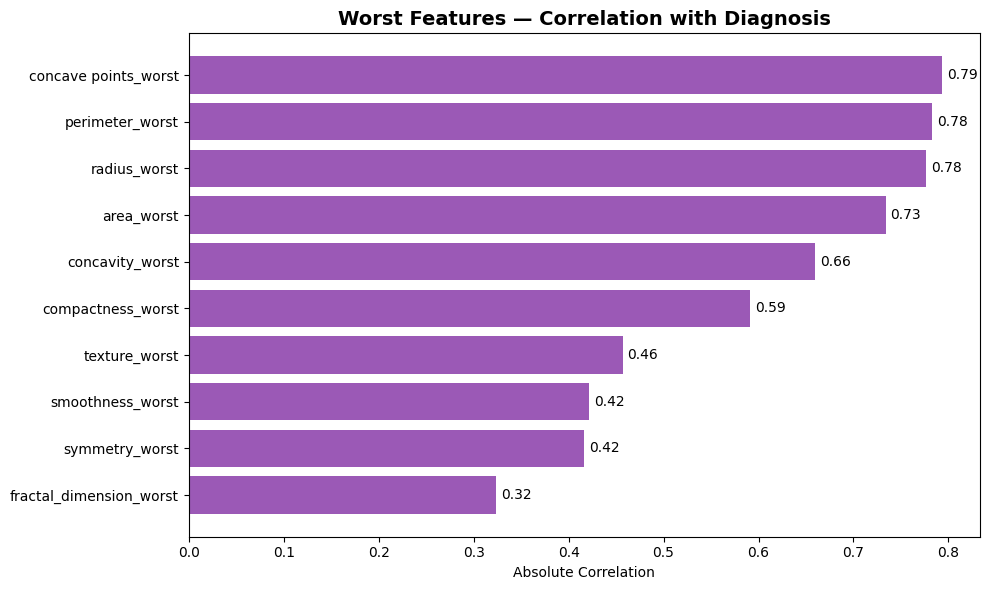

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

worst_corr = df[[c for c in df.columns if '_worst' in c]].corrwith(
    df['diagnosis_encoded']).abs().sort_values(ascending=False)

bars = ax.barh(worst_corr.index, worst_corr.values, color='#9b59b6')
ax.set_title('Worst Features — Correlation with Diagnosis', fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.invert_yaxis()

for bar, val in zip(bars, worst_corr.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/worst_features_corr.png', dpi=150)
plt.show()

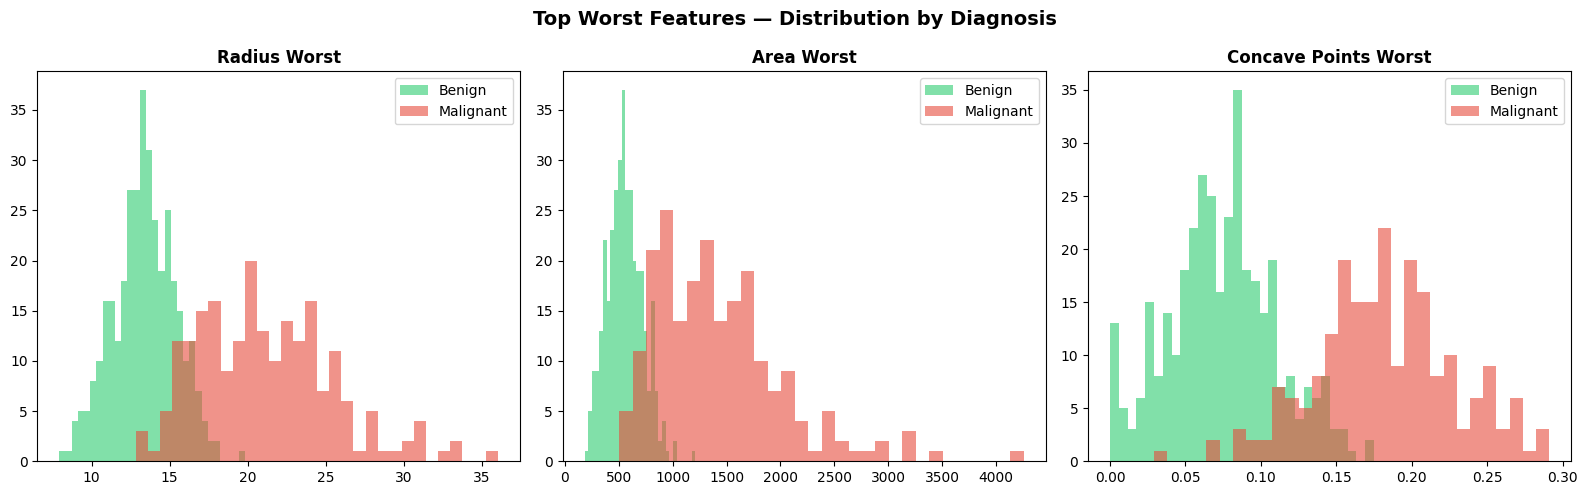

In [27]:
top3_worst = ['radius_worst', 'area_worst', 'concave points_worst']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(top3_worst):
    axes[i].hist(df[df['diagnosis']=='B'][col], bins=30,
                 alpha=0.6, color='#2ecc71', label='Benign')
    axes[i].hist(df[df['diagnosis']=='M'][col], bins=30,
                 alpha=0.6, color='#e74c3c', label='Malignant')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].legend()

fig.suptitle('Top Worst Features — Distribution by Diagnosis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/top3_worst_dist.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/1650796851.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f.replace('_mean','').replace('_se','').replace('_worst','')
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/1650796851.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f.replace('_mean','').replace('_se','').replace('_worst','')
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/1650796851.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f.replace('_mean','').replace('_se','').replace('_worst','')


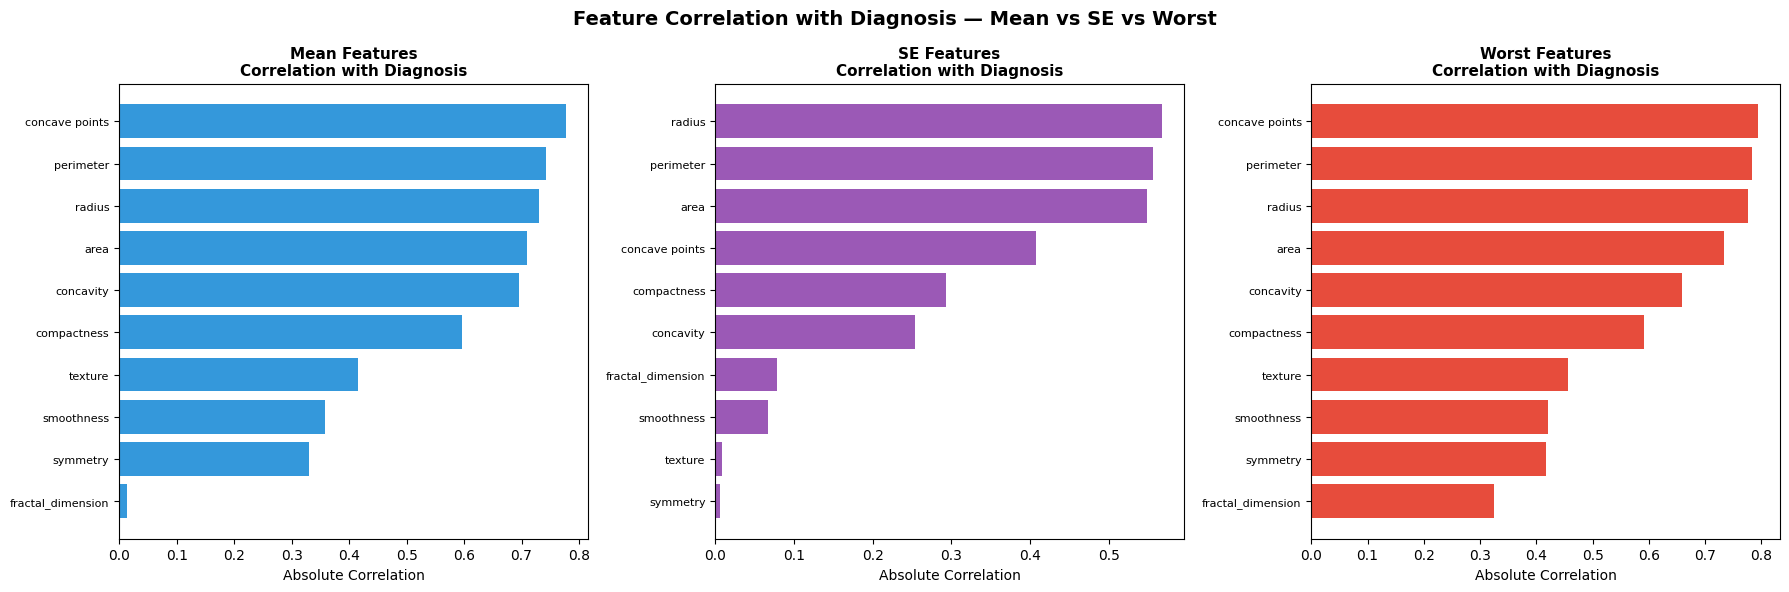

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

categories_map = {
    'Mean Features': [c for c in df.columns if '_mean' in c],
    'SE Features':   [c for c in df.columns if '_se' in c],
    'Worst Features':[c for c in df.columns if '_worst' in c]
}

for ax, (title, features) in zip(axes, categories_map.items()):
    corr = df[features].corrwith(df['diagnosis_encoded']).abs().sort_values(ascending=False)
    ax.barh(corr.index, corr.values,
            color='#3498db' if 'Mean' in title else '#9b59b6' if 'SE' in title else '#e74c3c')
    ax.set_title(f'{title}\nCorrelation with Diagnosis', fontsize=11, fontweight='bold')
    ax.set_xlabel('Absolute Correlation')
    ax.invert_yaxis()
    ax.set_yticklabels([f.replace('_mean','').replace('_se','').replace('_worst','')
                        for f in corr.index], fontsize=8)

fig.suptitle('Feature Correlation with Diagnosis — Mean vs SE vs Worst',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/corr_three_categories.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/2163618773.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/2163618773.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2950/2163618773.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='diagnosis', y=col,


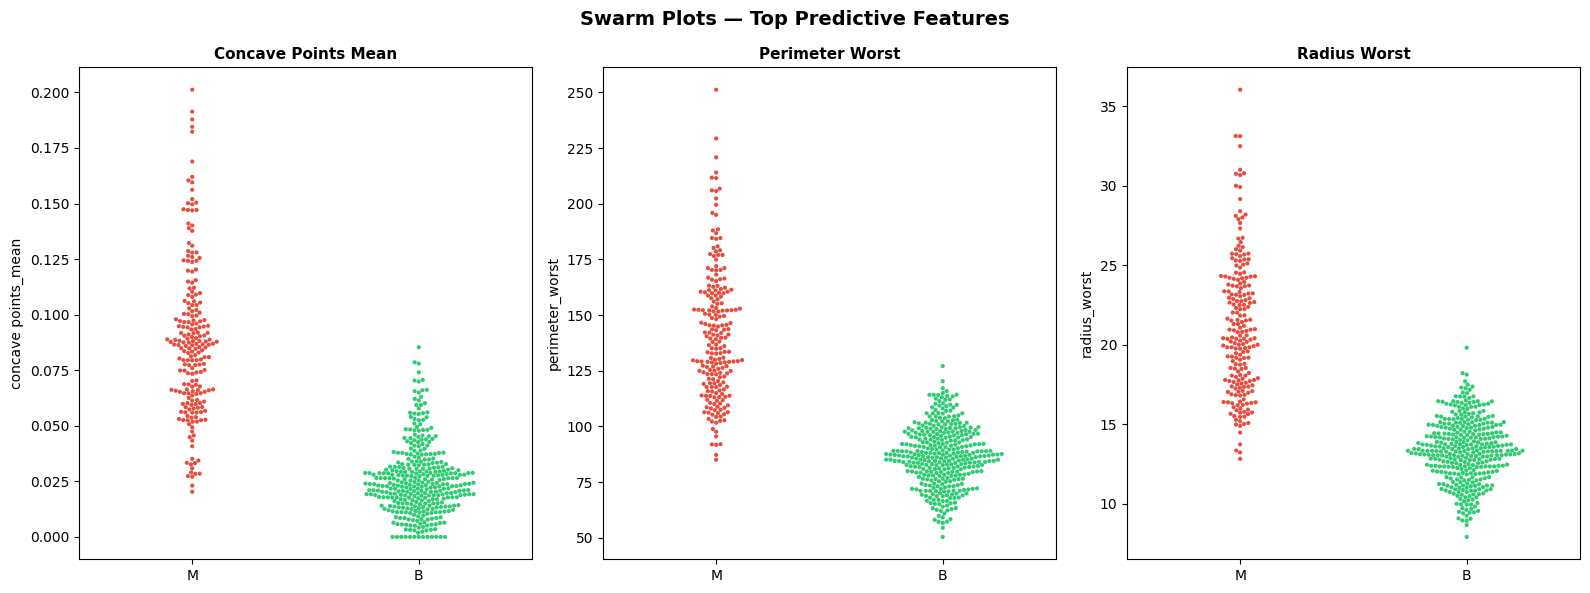

In [29]:
top3 = ['concave points_mean', 'perimeter_worst', 'radius_worst']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, col in enumerate(top3):
    sns.swarmplot(data=df, x='diagnosis', y=col,
                  palette=palette, ax=axes[i], size=3)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

fig.suptitle('Swarm Plots — Top Predictive Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/swarm_plots.png', dpi=150)
plt.show()